**<h3 style="color:orange">Please make sure any LLM coding assistant like Github Copilot or Cursus is turned OFF!</h2>**

**<h4 style="color:orange">We want you to learn and think critically, not to let LLMs do your work for you.</h4>**

**<h4 style="color:orange">Ask your group members or the internet for help, BEFORE asking your favorite chatbot.</h4>**

<img src="../figures/copilot.png">

# Assignment 1 Part 2: Modelling Boids as a Lagrangian System


In [75]:
# Import all the required libraries here
import torch as T
from torch import nn
from torch.utils.data import Dataset
from torch_geometric.data import Data, DataLoader as GraphDataLoader
import lightning as L
import os
import pickle
import time
import copy
import numpy as np
import matplotlib.pyplot as plt



print(f"Success! Running PyTorch {T.__version__} and Lightning {L.__version__}")
cuda_available = T.cuda.is_available()
if cuda_available:
    print(f"CUDA is available! Device count: {T.cuda.device_count()}")
else:
    print("CUDA is not available.")

print(f"MPS is available: {T.backends.mps.is_available()}")

Success! Running PyTorch 2.10.0 and Lightning 2.6.6
CUDA is not available.
MPS is available: True


In [76]:
class BoidsDataset(Dataset):
    """Dataset for the Boids simulation data."""

    def __init__(self, path):
        self.path = path
        self.nodes = T.tensor([], dtype=T.float32)
        self.edge_index = T.tensor([], dtype=T.long)
        self.edge_attributes = T.tensor([], dtype=T.float32)
        self.n_simulations = 0
        self.traj_length = 0

    def load_data(self):
        if not os.path.exists(self.path):
            raise FileNotFoundError(
                f"Data file not found at {self.path}. Please check the path and try again."
            )
        with open(self.path, "rb") as f:
            data = pickle.load(f)

        # TODO: Implement the logic to load nodes and edges from the data dictionary

        data = T.as_tensor(np.array(data), dtype=T.float32)  # (S, 50, N, 3)
        self.n_simulations = data.shape[0]
        n_boids = data.shape[2]

        # State = position + velocity, with v_t = x_t - x_{t-1}.
        # Frame 0 has no velocity, so samples start at t = 1 (48 per simulation).
        velocities = data[:, 1:] - data[:, :-1]      # (S, 49, N, 3)
        current_positions = data[:, 1:-1]            # x_t
        current_velocities = velocities[:, :-1]      # v_t
        next_positions = data[:, 2:]                 # x_{t+1}, target only

        # Node layout: [x_t (0:3) | v_t (3:6) | x_{t+1} (6:9, target)]
        self.nodes = T.cat(
            [current_positions, current_velocities, next_positions],
            dim=-1
        )
        self.traj_length = self.nodes.shape[1]

        # Fully connected directed graph without self-loops, row-major
        # (all neighbours of node 0, then node 1, ...). The EGNN relies on
        # this order for its k-nearest-neighbour selection.
        node_ids = T.arange(n_boids)
        row = node_ids.repeat_interleave(n_boids)
        col = node_ids.repeat(n_boids)
        mask = row != col
        row, col = row[mask], col[mask]

        base_edge_index = T.stack([row, col], dim=0)
        n_edges = base_edge_index.shape[1]

        # Same connectivity for every frame (expand is a view, no extra memory).
        self.edge_index = (
            base_edge_index
            .view(1, 1, 2, n_edges)
            .expand(self.n_simulations, self.traj_length, 2, n_edges)
        )

        # E(3)-invariant edge features for edge i (row) <- j (col),
        # computed lazily per sample (precomputing would need several GB):
        #   0: log(1 + |x_j - x_i|^2)           distance (must stay first: used for kNN)
        #   1: v_i . v_j                        velocity alignment
        #   2: |v_j - v_i|^2                    relative speed
        #   3: (x_j - x_i) . v_i / |x_j - x_i|  neighbour in front of / behind i

        class EdgeFeatureView:
            def __init__(self, positions, velocities, row, col, depth):
                self.positions = positions
                self.velocities = velocities
                self.row = row
                self.col = col
                self.depth = depth  # indexing levels before computing ([sim][t] -> 2)

            def __getitem__(self, idx):
                pos, vel = self.positions[idx], self.velocities[idx]

                if self.depth > 1:
                    return EdgeFeatureView(pos, vel, self.row, self.col, self.depth - 1)

                rel_pos = pos[..., self.col, :] - pos[..., self.row, :]
                dist_sq = rel_pos.square().sum(dim=-1, keepdim=True)
                v_i = vel[..., self.row, :]
                v_j = vel[..., self.col, :]

                return T.cat(
                    [
                        T.log1p(dist_sq),
                        (v_i * v_j).sum(dim=-1, keepdim=True),
                        (v_j - v_i).square().sum(dim=-1, keepdim=True),
                        (rel_pos * v_i).sum(dim=-1, keepdim=True)
                        / dist_sq.sqrt().clamp_min(1e-6),
                    ],
                    dim=-1
                )

        self.edge_attributes = EdgeFeatureView(
            positions=self.nodes[..., 0:3],
            velocities=self.nodes[..., 3:6],
            row=row,
            col=col,
            depth=2 if isinstance(self, BoidsStepDataset) else 1
        )

        print(
            f"\nLoaded data from {self.path}, containing {len(data)} samples of shape {data[0].shape}\n"
        )


class BoidsTrajectoryDataset(BoidsDataset):
    """One sample = one full trajectory: nodes has shape (traj_len, ...)."""

    def __len__(self):
        return self.n_simulations

    def __getitem__(self, idx):
        return Data(
            x=self.nodes[idx],
            edge_index=self.edge_index[idx],
            edge_attr=self.edge_attributes[idx]
        )


class BoidsStepDataset(BoidsDataset):
    """One sample = one timestep: nodes has shape (...)."""

    def __len__(self):
        return self.n_simulations * self.traj_length

    def __getitem__(self, idx):
        sim_idx, t_idx = idx // self.traj_length, idx % self.traj_length
        return Data(
            x=self.nodes[sim_idx][t_idx],
            edge_index=self.edge_index[sim_idx][t_idx],
            edge_attr=self.edge_attributes[sim_idx][t_idx]
        )


class DataModule(L.LightningDataModule):
    """Lightning DataModule class that manages the dataset splitting and the dataloaders"""

    def __init__(self, dataset, batch_size, train_split, val_split, seed=42):
        super().__init__()
        self.dataset = dataset
        self.batch_size = batch_size
        self.train_split = train_split
        self.val_split = val_split
        self.seed = seed

    def prepare_data(self):
        self.dataset.load_data()

    def setup(self, stage=None):
            if getattr(self, "train_set", None) is not None:
                return

            # TODO: Implement logic to split the dataset into train, validation, and test sets

            generator = T.Generator().manual_seed(self.seed)

            # Split complete simulations to avoid overlap between splits.
            simulation_indices = T.randperm(
                self.dataset.n_simulations,
                generator=generator
            ).tolist()

            n_train = int(self.dataset.n_simulations * self.train_split)
            n_val = int(self.dataset.n_simulations * self.val_split)

            train_sims = simulation_indices[:n_train]
            val_sims = simulation_indices[n_train:n_train + n_val]
            test_sims = simulation_indices[n_train + n_val:]

            # Retain simulation IDs for later evaluation.
            self.train_sims = train_sims
            self.val_sims = val_sims
            self.test_sims = test_sims

            if isinstance(self.dataset, BoidsStepDataset):

                def get_step_indices(simulations):
                    return [
                        sim * self.dataset.traj_length + t
                        for sim in simulations
                        for t in range(self.dataset.traj_length)
                    ]

                train_indices = get_step_indices(train_sims)
                val_indices = get_step_indices(val_sims)
                test_indices = get_step_indices(test_sims)

            else:
                train_indices = train_sims
                val_indices = val_sims
                test_indices = test_sims

            self.train_set = T.utils.data.Subset(self.dataset, train_indices)
            self.val_set = T.utils.data.Subset(self.dataset, val_indices)
            self.test_set = T.utils.data.Subset(self.dataset, test_indices)

    def train_dataloader(self):
        return GraphDataLoader(self.train_set, batch_size=self.batch_size)

    def val_dataloader(self):
        return GraphDataLoader(self.val_set, batch_size=self.batch_size)

    def test_dataloader(self):
        return GraphDataLoader(self.test_set, batch_size=self.batch_size)

    def predict_dataloader(self):
        return GraphDataLoader(self.test_set, batch_size=self.batch_size)


path = "/Users/linda/Desktop/TU:e/Q5/2AMM40 Machine Learning for Science/Assignments/boids_dataset.pkl"
boids_dataset = BoidsTrajectoryDataset(path=path)
boids_dataset.load_data()


Loaded data from /Users/linda/Desktop/TU:e/Q5/2AMM40 Machine Learning for Science/Assignments/boids_dataset.pkl, containing 2000 samples of shape torch.Size([50, 100, 3])



Number of simulations: 2000
Trajectory length: 50
Number of boids: 100
Spatial dimensions: 3
Position range per axis: [0.00021886825561523438, 1.996755599975586e-05, 0.00013697147369384766] -> [25.0, 25.0, 25.0]
Speed: mean 1.4920, std 0.0204, min 0.3337, max 1.5215
Turning angle per step: mean 14.14 deg, 95th pct 39.62 deg
Nearest-neighbour distance: mean 1.041, min 0.011


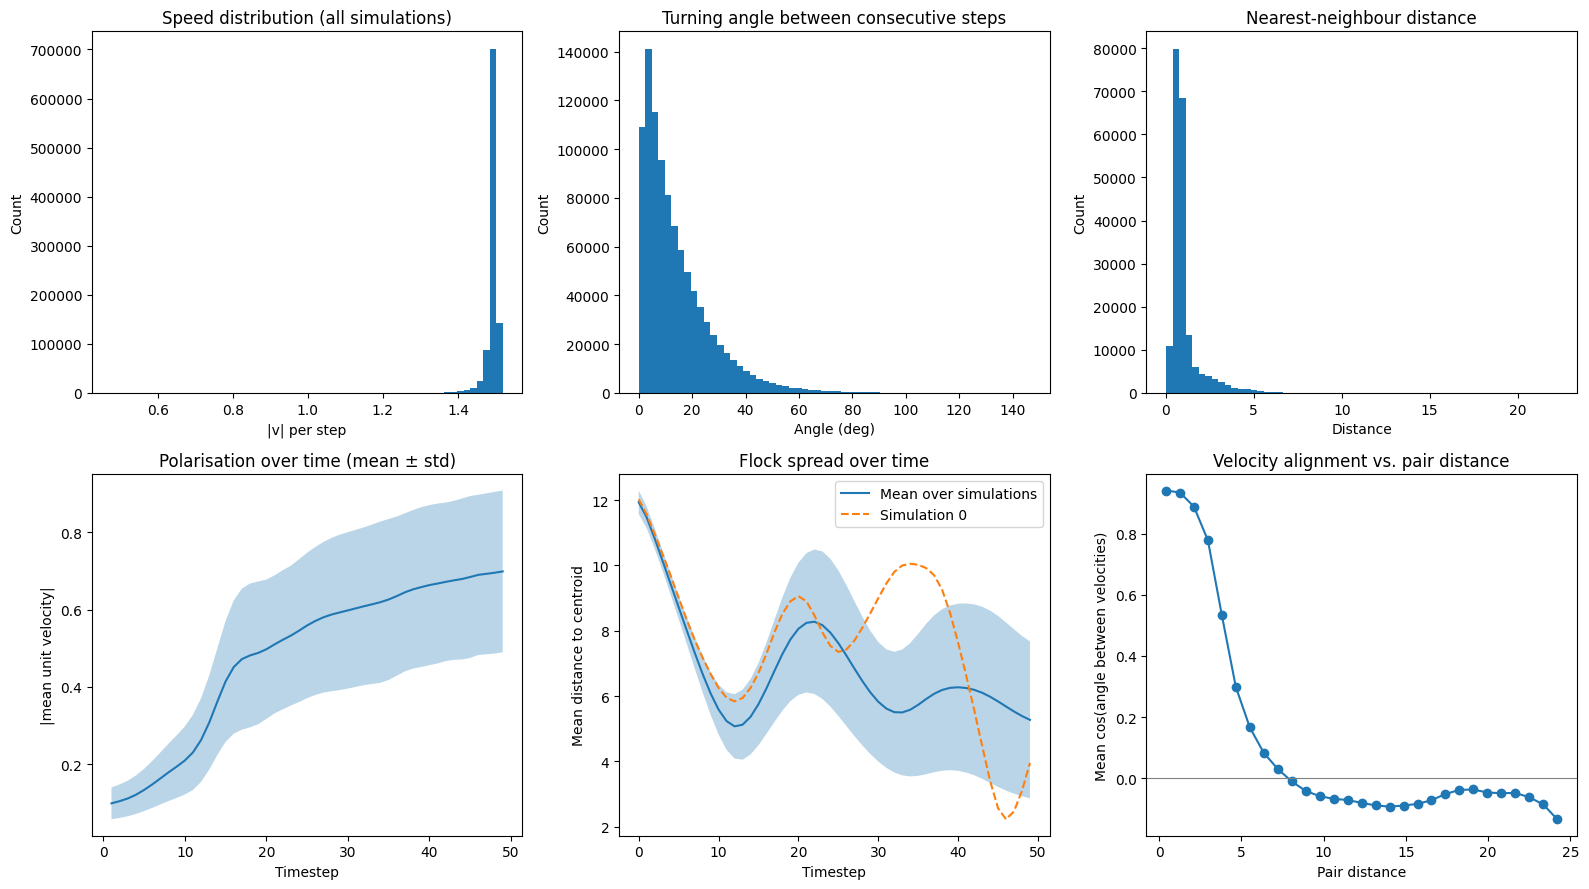

In [77]:
# Perform the exploratory data analysis here

with open(boids_dataset.path, "rb") as f:
    raw = pickle.load(f)
data = T.as_tensor(np.array(raw), dtype=T.float32)   # (S, T, N, 3)
del raw
S, T_len, N, D = data.shape

print("Number of simulations:", S)
print("Trajectory length:", T_len)
print("Number of boids:", N)
print("Spatial dimensions:", D)
print("Position range per axis:", data.amin(dim=(0, 1, 2)).tolist(), "->", data.amax(dim=(0, 1, 2)).tolist())

# Kinematics (time unit = one simulation step)
velocity = data[:, 1:] - data[:, :-1]                       # (S, T-1, N, 3)
speed = velocity.norm(dim=-1)                               # (S, T-1, N)
unit_velocity = velocity / speed.unsqueeze(-1).clamp_min(1e-8)

# Turning angle between consecutive velocity vectors
cos_turn = (unit_velocity[:, 1:] * unit_velocity[:, :-1]).sum(dim=-1).clamp(-1, 1)
turning_angle = T.rad2deg(T.acos(cos_turn))                 # (S, T-2, N)

# Polarisation = |mean unit velocity|: 1 = all aligned, ~0 = random directions
polarisation = unit_velocity.mean(dim=2).norm(dim=-1)       # (S, T-1)

# Flock spread = mean distance to the flock centroid
spread = (data - data.mean(dim=2, keepdim=True)).norm(dim=-1).mean(dim=2)   # (S, T)

print(f"Speed: mean {speed.mean():.4f}, std {speed.std():.4f}, min {speed.min():.4f}, max {speed.max():.4f}")
print(f"Turning angle per step: mean {turning_angle.mean():.2f} deg, "
      f"95th pct {turning_angle.flatten()[::10].quantile(0.95):.2f} deg")

# Interactions (subsample: 200 simulations, every 5th frame)
sub_pos = data[:200, 1::5]                    # x_t
sub_vel = velocity[:200, 0::5]                # v_t = x_t - x_{t-1}, same frames
frames_pos = sub_pos.flatten(0, 1)            # (F, N, 3)
frames_vel = sub_vel.flatten(0, 1)

pair_dist = T.cdist(frames_pos, frames_pos)   # (F, N, N)
eye = T.eye(N, dtype=T.bool)
nearest_neighbour = pair_dist.masked_fill(eye, float("inf")).min(dim=-1).values

frames_unit = frames_vel / frames_vel.norm(dim=-1, keepdim=True).clamp_min(1e-8)
pair_cos = frames_unit @ frames_unit.transpose(1, 2)   # velocity alignment of each pair

off_diag = ~eye.expand_as(pair_dist)
d_flat = pair_dist[off_diag].numpy()
c_flat = pair_cos[off_diag].numpy()
bins = np.linspace(0, np.percentile(d_flat, 99), 30)
bin_id = np.clip(np.digitize(d_flat, bins) - 1, 0, len(bins) - 2)
mean_cos = np.bincount(bin_id, weights=c_flat, minlength=len(bins) - 1) / np.maximum(
    np.bincount(bin_id, minlength=len(bins) - 1), 1)
bin_centres = 0.5 * (bins[1:] + bins[:-1])

print(f"Nearest-neighbour distance: mean {nearest_neighbour.mean():.3f}, min {nearest_neighbour.min():.3f}")

# Plots
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

axes[0, 0].hist(speed.flatten()[::10].numpy(), bins=60)
axes[0, 0].set(title="Speed distribution (all simulations)", xlabel="|v| per step", ylabel="Count")

axes[0, 1].hist(turning_angle.flatten()[::10].numpy(), bins=60)
axes[0, 1].set(title="Turning angle between consecutive steps", xlabel="Angle (deg)", ylabel="Count")

axes[0, 2].hist(nearest_neighbour.flatten().numpy(), bins=60)
axes[0, 2].set(title="Nearest-neighbour distance", xlabel="Distance", ylabel="Count")

t_vel = np.arange(1, T_len)
m, s = polarisation.mean(0).numpy(), polarisation.std(0).numpy()
axes[1, 0].plot(t_vel, m)
axes[1, 0].fill_between(t_vel, m - s, m + s, alpha=0.3)
axes[1, 0].set(title="Polarisation over time (mean ± std)", xlabel="Timestep", ylabel="|mean unit velocity|")

t_pos = np.arange(T_len)
m, s = spread.mean(0).numpy(), spread.std(0).numpy()
axes[1, 1].plot(t_pos, m, label="Mean over simulations")
axes[1, 1].fill_between(t_pos, m - s, m + s, alpha=0.3)
axes[1, 1].plot(t_pos, spread[0].numpy(), "--", label="Simulation 0")
axes[1, 1].set(title="Flock spread over time", xlabel="Timestep", ylabel="Mean distance to centroid")
axes[1, 1].legend()

axes[1, 2].plot(bin_centres, mean_cos, marker="o")
axes[1, 2].axhline(0, color="grey", lw=0.8)
axes[1, 2].set(title="Velocity alignment vs. pair distance", xlabel="Pair distance",
               ylabel="Mean cos(angle between velocities)")

plt.tight_layout()
plt.show()

del pair_dist, pair_cos, d_flat, c_flat

Position min per axis: [0.0, 0.0, 0.0]
Position max per axis: [25.0, 25.0, 25.0]
Mean number of neighbours within r =  3: 28.1
Mean number of neighbours within r =  5: 37.2
Mean number of neighbours within r =  7: 43.9
Mean number of neighbours within r = 10: 55.6
Fraction of boids within 2 units of a wall: 0.019


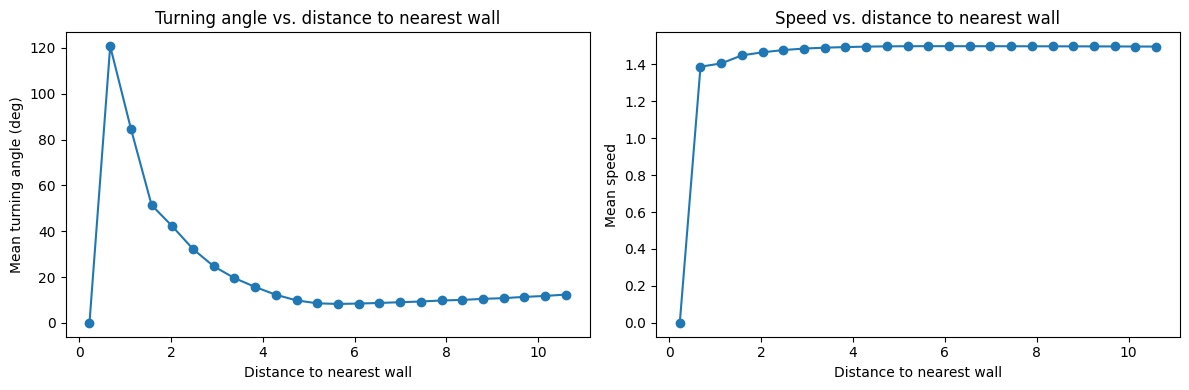

In [78]:
# neighbourhood size and boundary effects
box_min = data.amin(dim=(0, 1, 2))
box_max = data.amax(dim=(0, 1, 2))
print("Position min per axis:", [round(v, 3) for v in box_min.tolist()])
print("Position max per axis:", [round(v, 3) for v in box_max.tolist()])

# 1. How many neighbours lie within the interaction range?
frames = data[:200, 1::5].flatten(0, 1)                 # (F, N, 3)
d = T.cdist(frames, frames)
for r in [3, 5, 7, 10]:
    n_within = ((d < r).sum(dim=-1) - 1).float()        # exclude self
    print(f"Mean number of neighbours within r = {r:>2}: {n_within.mean():.1f}")
del d

# 2. Do boids behave differently near the walls?
pos_mid = data[:, 1:-1]                                              # (S, T-2, N, 3)
wall_dist = T.minimum(pos_mid - box_min, box_max - pos_mid).amin(dim=-1)   # (S, T-2, N)
speed_mid = speed[:, 1:]                                             # speed after the turn

w = wall_dist.flatten()[::10].numpy()
a = turning_angle.flatten()[::10].numpy()
v = speed_mid.flatten()[::10].numpy()

bins = np.linspace(0, np.percentile(w, 99), 25)
idx = np.clip(np.digitize(w, bins) - 1, 0, len(bins) - 2)
counts = np.maximum(np.bincount(idx, minlength=len(bins) - 1), 1)
centres = 0.5 * (bins[1:] + bins[:-1])

print(f"Fraction of boids within 2 units of a wall: {(wall_dist < 2).float().mean():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(centres, np.bincount(idx, weights=a, minlength=len(bins) - 1) / counts, marker="o")
axes[0].set(title="Turning angle vs. distance to nearest wall",
            xlabel="Distance to nearest wall", ylabel="Mean turning angle (deg)")
axes[1].plot(centres, np.bincount(idx, weights=v, minlength=len(bins) - 1) / counts, marker="o")
axes[1].set(title="Speed vs. distance to nearest wall",
            xlabel="Distance to nearest wall", ylabel="Mean speed")
plt.tight_layout()
plt.show()

In [79]:
class EGNN(nn.Module):

    def __init__(self):
        super().__init__()
        # TODO: Initialize the EGNN architecture here

        # Input  x: (N, 6) = [position | velocity]
        # Output  : (N, 6) = [next position | next velocity]
        self.k = 16          # nearest neighbours per boid (alignment range ~5-8 in EDA)
        hidden_dim = 64
        n_layers = 2
        edge_dim = 4         # edge features from BoidsDataset

        # Invariant node embedding from speed |v_i|
        self.node_embedding = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        # Invariant message passing on node features h
        self.edge_mlps = nn.ModuleList([
            nn.Sequential(
                nn.Linear(2 * hidden_dim + edge_dim, hidden_dim),
                nn.SiLU(),
                nn.Linear(hidden_dim, hidden_dim),
                nn.SiLU()
            )
            for _ in range(n_layers)
        ])
        self.node_mlps = nn.ModuleList([
            nn.Sequential(
                nn.Linear(2 * hidden_dim, hidden_dim),
                nn.SiLU(),
                nn.Linear(hidden_dim, hidden_dim)
            )
            for _ in range(n_layers)
        ])

        # Scalar heads for the equivariant velocity update (one per boids rule)
        def scalar_head():
            return nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.SiLU(),
                nn.Linear(hidden_dim, 1)
            )

        self.position_head = scalar_head()    # cohesion / separation
        self.alignment_head = scalar_head()   # alignment
        self.inertia_head = scalar_head()     # speed change

        # Zero-init last layers: the untrained model equals the
        # constant-velocity baseline, training learns a correction.
        for head in [self.position_head, self.alignment_head, self.inertia_head]:
            nn.init.zeros_(head[-1].weight)
            nn.init.zeros_(head[-1].bias)

    def forward(self, x, edge_index, edge_attr):

        # TODO: Implement the forward pass of the EGNN here

        pos, vel = x[:, 0:3], x[:, 3:6]
        n_nodes = x.shape[0]
        row, col = edge_index

        # 1. Keep the k nearest neighbours. Assumes the row-major fully
        #    connected graph from BoidsDataset; edge_attr[:, 0] = log(1 + d^2).
        neighbors_per_node = row.numel() // n_nodes
        k = min(self.k, neighbors_per_node)

        distance_matrix = edge_attr[:, 0].reshape(n_nodes, neighbors_per_node)
        nearest_indices = distance_matrix.topk(k, dim=1, largest=False, sorted=False).indices
        offsets = T.arange(n_nodes, device=x.device).unsqueeze(1) * neighbors_per_node
        selected_edges = (nearest_indices + offsets).reshape(-1)

        row, col = row[selected_edges], col[selected_edges]
        edge_attr = edge_attr[selected_edges]

        # 2. Invariant node features, refined by message passing
        h = self.node_embedding(vel.norm(dim=-1, keepdim=True))

        for edge_mlp, node_mlp in zip(self.edge_mlps, self.node_mlps):
            messages = edge_mlp(T.cat([h[row], h[col], edge_attr], dim=-1))
            aggregated = h.new_zeros(n_nodes, h.shape[-1]).index_add_(0, row, messages) / k
            h = h + node_mlp(T.cat([h, aggregated], dim=-1))

        # 3. Equivariant velocity update: invariant scalar x equivariant vector
        rel_pos = pos[col] - pos[row]                     # x_j - x_i
        rel_vel = vel[col] - vel[row]                     # v_j - v_i
        dist = rel_pos.norm(dim=-1, keepdim=True)

        cohesion = T.zeros_like(pos).index_add_(
            0, row, rel_pos / (1.0 + dist) * T.tanh(self.position_head(messages))
        ) / k
        alignment = T.zeros_like(vel).index_add_(
            0, row, rel_vel * T.tanh(self.alignment_head(messages))
        ) / k

        # Direction: current heading corrected by the neighbour terms.
        direction = vel + cohesion + alignment

        # Speed is nearly constant in the data, so it may change by at most 5%
        # per step. This keeps the autoregressive rollout stable.
        speed = vel.norm(dim=-1, keepdim=True)
        next_speed = speed * (1.0 + 0.05 * T.tanh(self.inertia_head(h)))
        next_vel = direction / direction.norm(dim=-1, keepdim=True).clamp_min(1e-6) * next_speed

        next_pos = pos + next_vel

        return T.cat([next_pos, next_vel], dim=-1)

In [80]:
class BoidsModel(L.LightningModule):
    def __init__(self, model, learning_rate=1e-3):
        super().__init__()
        self.model = model
        self.learning_rate = learning_rate

    def forward(self, x):
        return self.model(x)

    def _step(self, batch):

        # TODO Implement the logic for a single training/validation step here

        # Model input: current state only (position + velocity)
        state = batch.x[:, 0:6]
        # Target velocity v_{t+1} = x_{t+1} - x_t
        target_velocity = batch.x[:, 6:9] - batch.x[:, 0:3]

        prediction = self.model(state, batch.edge_index, batch.edge_attr)

        # Equal to the MSE on the next position, since x_{t+1} = x_t + v_{t+1}
        loss = nn.functional.mse_loss(prediction[:, 3:6], target_velocity)

        return loss

    def training_step(self, batch):
        loss = self._step(batch)
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch):
        loss = self._step(batch)
        self.log("val_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def predict_step(self, batch):

        # TODO Implement the logic for autoregressive rollout here

        if batch.num_graphs != 1:
            raise ValueError("Use batch_size=1 for autoregressive trajectory prediction.")

        trajectory = batch.x                      # (T, N, 9)
        edge_index = batch.edge_index[0]          # same candidate graph every step
        row, col = edge_index

        # Initial state (x_1, v_1) from ground truth, afterwards only predictions
        position = trajectory[0, :, 0:3]
        velocity = trajectory[0, :, 3:6]
        rollout = [position]

        for _ in range(trajectory.shape[0]):
            # Recompute edge features from the predicted state
            # (must match BoidsDataset exactly)
            rel_pos = position[col] - position[row]
            dist_sq = rel_pos.square().sum(dim=-1, keepdim=True)
            v_i, v_j = velocity[row], velocity[col]
            edge_attr = T.cat(
                [
                    T.log1p(dist_sq),
                    (v_i * v_j).sum(dim=-1, keepdim=True),
                    (v_j - v_i).square().sum(dim=-1, keepdim=True),
                    (rel_pos * v_i).sum(dim=-1, keepdim=True)
                    / dist_sq.sqrt().clamp_min(1e-6),
                ],
                dim=-1
            )

            next_state = self.model(
                T.cat([position, velocity], dim=-1), edge_index, edge_attr
            )
            position, velocity = next_state[:, 0:3], next_state[:, 3:6]
            rollout.append(position)

        return T.stack(rollout, dim=0)           # (T + 1, N, 3)

    def configure_optimizers(self):
        return T.optim.Adam(self.parameters(), lr=self.learning_rate)


class LossHistory(L.Callback):
    def __init__(self):
        self.train_loss, self.val_loss = [], []

    def on_train_epoch_end(self, trainer, pl_module):
        self.train_loss.append(trainer.callback_metrics.get("train_loss").item())

    def on_validation_epoch_end(self, trainer, pl_module):
        self.val_loss.append(trainer.callback_metrics.get("val_loss").item())

In [81]:
# Initialize dataset
dataset = BoidsStepDataset(path)

# Initialize datamodule
datamodule = DataModule(
    dataset,
    batch_size=32,
    train_split=0.8,
    val_split=0.1
)

# Initialize model
egnn = EGNN()
model = BoidsModel(egnn)

# Initialize trainer
loss_history = LossHistory()
trainer = L.Trainer(
    callbacks=[loss_history],
    max_epochs=30,
    num_sanity_val_steps=0
)

# Fit the model to the dataset
trainer.fit(model, datamodule=datamodule)

# Load the inference dataset
traj_dataset = BoidsTrajectoryDataset(path)

datamodule = DataModule(
    traj_dataset,
    batch_size=1,
    train_split=0.8,
    val_split=0.1
)

# Perform inference
rollouts = trainer.predict(
    model,
    datamodule=datamodule
)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.



Loaded data from /Users/linda/Desktop/TU:e/Q5/2AMM40 Machine Learning for Science/Assignments/boids_dataset.pkl, containing 2000 samples of shape torch.Size([50, 100, 3])



┏━━━┳━━━━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ EGNN │ 67.1 K │ train │     0 │
└───┴───────┴──────┴────────┴───────┴───────┘

Trainable params: 67.1 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 67.1 K                                                                                               
Total estimated model params size (MB): 0.269                                                                      
Modules in train mode: 37                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=30` reached.



Loaded data from /Users/linda/Desktop/TU:e/Q5/2AMM40 Machine Learning for Science/Assignments/boids_dataset.pkl, containing 2000 samples of shape torch.Size([50, 100, 3])



Output()

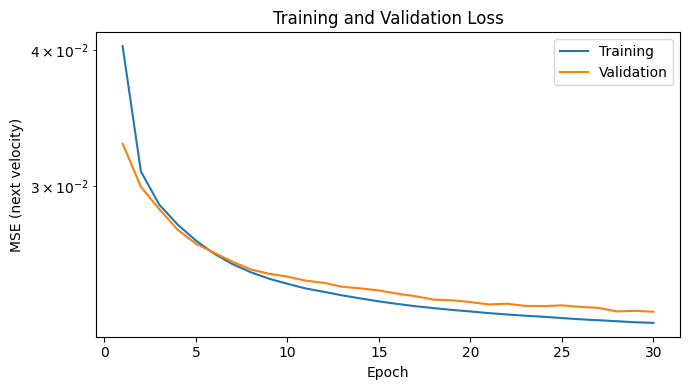

Method                1-step error       ADE       FDE
EGNN                        0.3224   12.1968   18.0447
Constant velocity           0.6296   34.3099   67.2218
Static                      1.4872   13.2841   13.5029


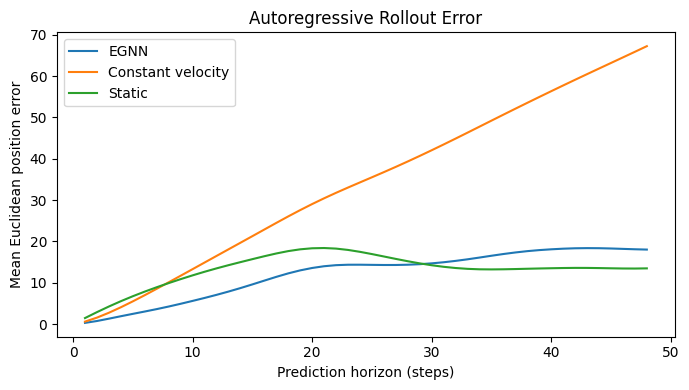

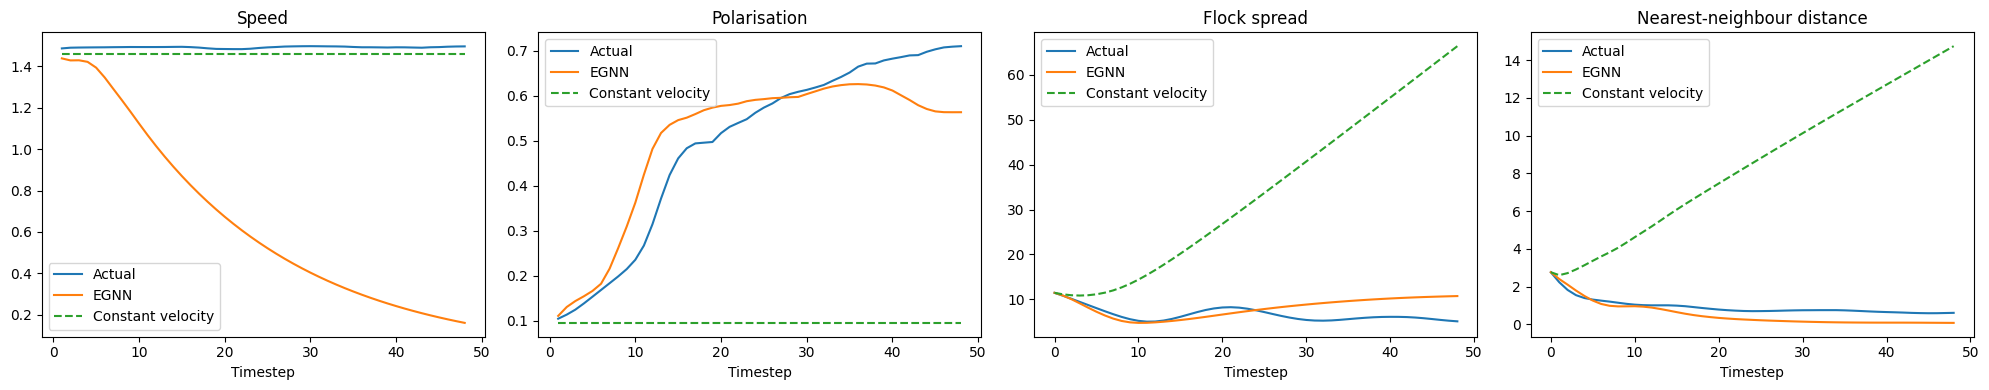

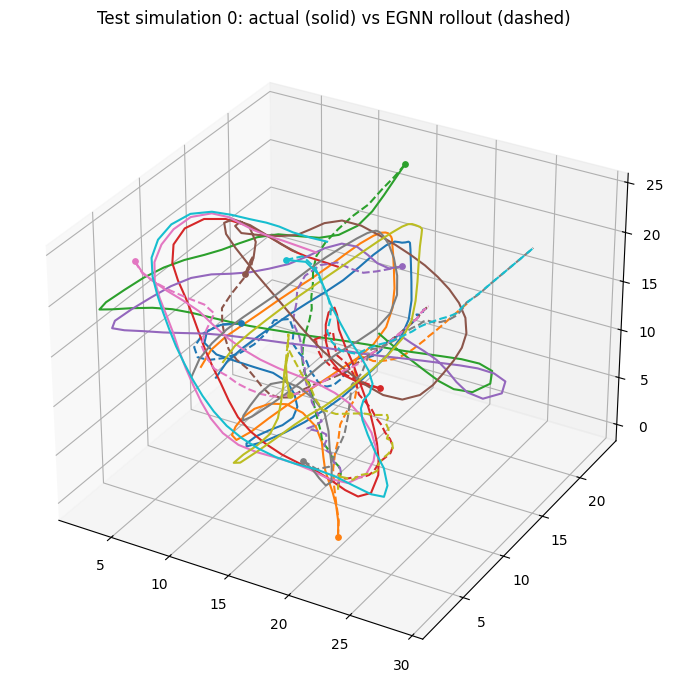

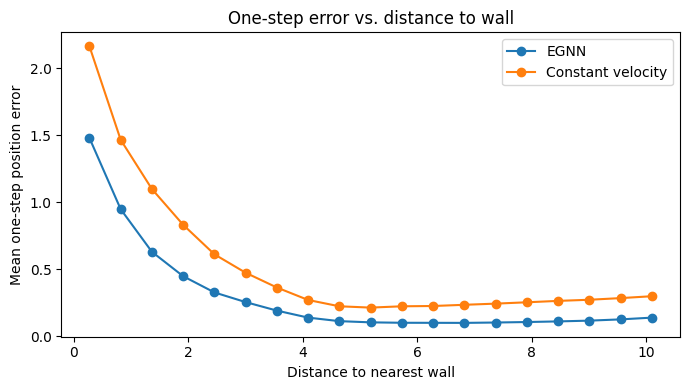

Equivariance check: det(Q) = +1.0, max |f(gx) - g f(x)| = 2.86e-06
Trainable parameters: 67139
Edges per frame: full graph 9900, kNN graph 1600 (16.2% of full)
CPU time per step: edge features 0.45 ms, EGNN 1.91 ms
CPU time for one 48-step rollout: 113.3 ms


In [82]:
# Evaluate the model and make plots here

def edge_features(pos, vel, row, col):
    # Same features as in BoidsDataset
    rel_pos = pos[col] - pos[row]
    dist_sq = rel_pos.square().sum(dim=-1, keepdim=True)
    v_i, v_j = vel[row], vel[col]
    return T.cat(
        [
            T.log1p(dist_sq),
            (v_i * v_j).sum(dim=-1, keepdim=True),
            (v_j - v_i).square().sum(dim=-1, keepdim=True),
            (rel_pos * v_i).sum(dim=-1, keepdim=True) / dist_sq.sqrt().clamp_min(1e-6),
        ],
        dim=-1
    )

# 1. Training and validation loss
train_losses = loss_history.train_loss
val_losses = loss_history.val_loss
if len(val_losses) == len(train_losses) + 1:
    val_losses = val_losses[1:]

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(train_losses) + 1), train_losses, label="Training")
plt.plot(range(1, len(val_losses) + 1), val_losses, label="Validation")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("MSE (next velocity)")
plt.title("Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

# 2. Predicted, actual and baseline trajectories
predicted = T.stack([r.detach().cpu() for r in rollouts])     # (S_test, 49, N, 3)
test_nodes = traj_dataset.nodes[datamodule.test_sims]        # (S_test, 48, N, 9)

x0 = test_nodes[:, 0, :, 0:3]                                 # initial position x_1
v0 = test_nodes[:, 0, :, 3:6]                                 # initial velocity v_1
actual = T.cat([x0.unsqueeze(1), test_nodes[:, :, :, 6:9]], dim=1)
assert predicted.shape == actual.shape

n_frames = actual.shape[1]
steps = T.arange(n_frames, dtype=T.float32).view(1, -1, 1, 1)

methods = {
    "EGNN": predicted,
    "Constant velocity": x0.unsqueeze(1) + steps * v0.unsqueeze(1),
    "Static": x0.unsqueeze(1).expand_as(actual),
}

# 3. Displacement errors (initial frame is given, so excluded)
print(f"{'Method':<20}{'1-step error':>14}{'ADE':>10}{'FDE':>10}")
errors = {}
for name, pos in methods.items():
    e = (pos[:, 1:] - actual[:, 1:]).norm(dim=-1)            # (S_test, 48, N)
    errors[name] = e
    print(f"{name:<20}{e[:, 0].mean():>14.4f}{e.mean():>10.4f}{e[:, -1].mean():>10.4f}")

plt.figure(figsize=(7, 4))
for name, e in errors.items():
    plt.plot(range(1, n_frames), e.mean(dim=(0, 2)).numpy(), label=name)
plt.xlabel("Prediction horizon (steps)")
plt.ylabel("Mean Euclidean position error")
plt.title("Autoregressive Rollout Error")
plt.legend()
plt.tight_layout()
plt.show()

# 4. Kinematic and interaction properties: actual vs predicted
def nearest_neighbour_distance(pos, chunk=2000):
    frames = pos.flatten(0, 1)
    eye = T.eye(frames.shape[1], dtype=T.bool)
    out = [T.cdist(f, f).masked_fill(eye, float("inf")).min(dim=-1).values
           for f in frames.split(chunk)]
    return T.cat(out).view(pos.shape[0], pos.shape[1], -1)

def kinematics(pos):
    vel = pos[:, 1:] - pos[:, :-1]
    speed = vel.norm(dim=-1)
    unit = vel / speed.unsqueeze(-1).clamp_min(1e-8)
    return {
        "Speed": speed.mean(dim=(0, 2)),
        "Polarisation": unit.mean(dim=2).norm(dim=-1).mean(dim=0),
        "Flock spread": (pos - pos.mean(dim=2, keepdim=True)).norm(dim=-1).mean(dim=(0, 2)),
        "Nearest-neighbour distance": nearest_neighbour_distance(pos).mean(dim=(0, 2)),
    }

stats = {name: kinematics(pos) for name, pos in
         [("Actual", actual), ("EGNN", predicted), ("Constant velocity", methods["Constant velocity"])]}

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, key in zip(axes, stats["Actual"].keys()):
    for name, s in stats.items():
        values = s[key].numpy()
        start = 1 if key in ("Speed", "Polarisation") else 0
        ax.plot(range(start, start + len(values)), values, label=name,
                ls="--" if name == "Constant velocity" else "-")
    ax.set(title=key, xlabel="Timestep")
    ax.legend()
plt.tight_layout()
plt.show()

# 5. Example 3D trajectories (first 10 boids of one test simulation)
sim = 0
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(projection="3d")
for b in range(10):
    a = actual[sim, :, b].numpy()
    p = predicted[sim, :, b].numpy()
    line, = ax.plot(*a.T, lw=1.5)
    ax.plot(*p.T, ls="--", lw=1.5, color=line.get_color())
    ax.scatter(*a[0], color=line.get_color(), s=15)
ax.set_title("Test simulation 0: actual (solid) vs EGNN rollout (dashed)")
plt.tight_layout()
plt.show()

# 6. One-step error vs distance to the nearest wall (50 test simulations)
egnn_cpu = copy.deepcopy(model.model).cpu().eval()
full_edge_index = traj_dataset.edge_index[0, 0]
row, col = full_edge_index

def one_step(pos, vel):
    return egnn_cpu(T.cat([pos, vel], dim=-1), full_edge_index, edge_features(pos, vel, row, col))

all_pos = traj_dataset.nodes[..., 0:3]
box_min = all_pos.amin(dim=(0, 1, 2))
box_max = all_pos.amax(dim=(0, 1, 2))

wall, err_egnn, err_cv = [], [], []
with T.no_grad():
    for s in range(50):
        for t in range(test_nodes.shape[1]):
            pos, vel, target = test_nodes[s, t, :, 0:3], test_nodes[s, t, :, 3:6], test_nodes[s, t, :, 6:9]
            pred = one_step(pos, vel)[:, 0:3]
            wall.append(T.minimum(pos - box_min, box_max - pos).amin(dim=-1))
            err_egnn.append((pred - target).norm(dim=-1))
            err_cv.append((pos + vel - target).norm(dim=-1))

wall = T.cat(wall).numpy()
err_egnn = T.cat(err_egnn).numpy()
err_cv = T.cat(err_cv).numpy()

bins = np.linspace(0, np.percentile(wall, 99), 20)
idx = np.clip(np.digitize(wall, bins) - 1, 0, len(bins) - 2)
counts = np.bincount(idx, minlength=len(bins) - 1)
centres = 0.5 * (bins[1:] + bins[:-1])
valid = counts > 0

plt.figure(figsize=(7, 4))
for name, err in [("EGNN", err_egnn), ("Constant velocity", err_cv)]:
    mean_err = np.bincount(idx, weights=err, minlength=len(bins) - 1) / np.maximum(counts, 1)
    plt.plot(centres[valid], mean_err[valid], marker="o", label=name)
plt.xlabel("Distance to nearest wall")
plt.ylabel("Mean one-step position error")
plt.title("One-step error vs. distance to wall")
plt.legend()
plt.tight_layout()
plt.show()

# 7. Numerical E(3)-equivariance check
T.manual_seed(0)
Q, _ = T.linalg.qr(T.randn(3, 3))          # random orthogonal matrix (rotation or reflection)
shift = 10 * T.randn(3)
pos, vel = test_nodes[0, 10, :, 0:3], test_nodes[0, 10, :, 3:6]

with T.no_grad():
    out = one_step(pos, vel)
    out_transformed = one_step(pos @ Q.T + shift, vel @ Q.T)
    expected = T.cat([out[:, 0:3] @ Q.T + shift, out[:, 3:6] @ Q.T], dim=-1)

print(f"Equivariance check: det(Q) = {T.det(Q):+.1f}, "
      f"max |f(gx) - g f(x)| = {(out_transformed - expected).abs().max():.2e}")

# 8. Computational efficiency
n_params = sum(p.numel() for p in egnn_cpu.parameters())
n_boids = actual.shape[2]
n_full_edges = row.numel()
n_knn_edges = n_boids * min(egnn_cpu.k, n_boids - 1)

with T.no_grad():
    n_repeats = 200
    t0 = time.perf_counter()
    for _ in range(n_repeats):
        ea = edge_features(pos, vel, row, col)
    t_features = (time.perf_counter() - t0) / n_repeats
    t0 = time.perf_counter()
    for _ in range(n_repeats):
        egnn_cpu(T.cat([pos, vel], dim=-1), full_edge_index, ea)
    t_model = (time.perf_counter() - t0) / n_repeats

print(f"Trainable parameters: {n_params}")
print(f"Edges per frame: full graph {n_full_edges}, kNN graph {n_knn_edges} "
      f"({100 * n_knn_edges / n_full_edges:.1f}% of full)")
print(f"CPU time per step: edge features {1e3 * t_features:.2f} ms, EGNN {1e3 * t_model:.2f} ms")
print(f"CPU time for one {n_frames - 1}-step rollout: {1e3 * (n_frames - 1) * (t_features + t_model):.1f} ms")

In [83]:
print(train_losses[0], train_losses[-1], val_losses[-1])

0.040322598069906235 0.022475508973002434 0.02301228605210781
